# DSA4262 Assignment 1
## Depression within International Students in University



### Import Modules and Load Data

In [240]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import cm

df_a = pd.read_csv("data.csv")
df_b = pd.read_csv("Green_Campus_Multifactor_Dataset.csv")

### Sources
1. Dataset of Students' Mental Health and Help-Seeking Behaviours in a Multicultural Environment (https://www.mdpi.com/2306-5729/4/3/124/s1) 

This Dataset comprises 268 records from International and Domestic Students from an International University in Japan. To obtain the data, students submitted a Google Form. The Dataset, which contained socio-demographic information, mental health conditions and help-seeking behaviours were derived from self-reported scales of the students. PHQ-9 Scores were tabulated from 9 Depression Indicator Questions (rated from 0-1), which were then taken into account to categorise students under 3 Types; No Disorder, Other Depressive Disorder and Major Depressive Disorder. Total Social Connectedness of Students were measured using the Social Connectedness Scores. Total Acculturative Stress Scores of Students were tabulated from the sum of total scores of Perceived Discrimination, Homesickness, Perceived Hatred, Fear, Culture Shock, Guit, Miscellaneous measured by the Acculturative Stress Scale for International Students (ASSIS). While the dataset is credible, the dataset is made up of 75% responses from International Students and 25% from Local Students.

2. Green Campus Health Dataset (https://www.kaggle.com/datasets/programmer3/green-campus-health-dataset)

This Dataset comprises 458 records from University Students, including information such as Demographic Features, Lifestyle and Behavioural Features, Psychological Factors, Physicological Factors, Environmental Factors, Academic Factors and Social Factors. The source of the data is unknown, which makes it quite credible.

### Macro Plot

### Macro Plot

C:\Users\Haidah\AppData\Local\Temp\ipykernel_43768\2122352072.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_1.groupby(['inter_dom', 'DepType']).size().reset_index(name='Count')


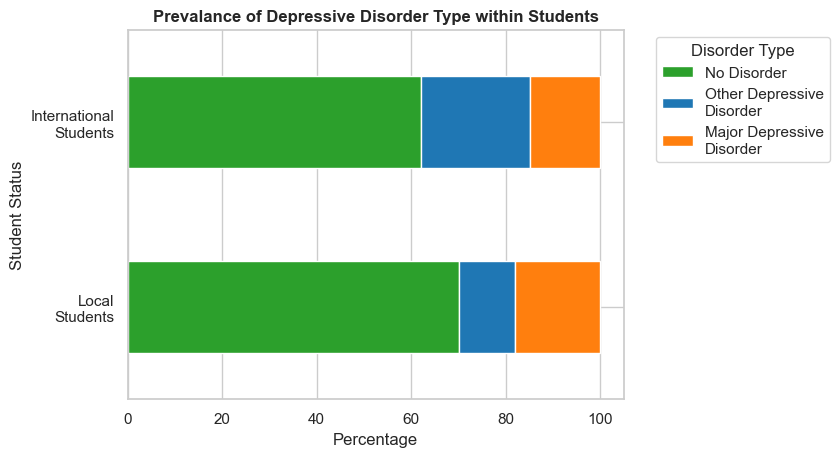

In [245]:
df_1 = df_a.copy()

df_1["DepType"] = pd.Categorical(df_1["DepType"], categories =["No", "Other", "Major"], ordered=True)
df_1['DepType'] = df_1['DepType'].map({'No': 'No Disorder','Other': 'Other Depressive\nDisorder','Major' : 'Major Depressive\nDisorder'})

counts = df_1.groupby(['inter_dom', 'DepType']).size().reset_index(name='Count')
counts['Percent'] = counts.groupby('inter_dom')['Count'].transform(lambda x: x / x.sum() * 100)

pivot_df = counts.pivot(index='inter_dom', columns='DepType', values='Percent').fillna(0)

pivot_df = pivot_df.loc[["Dom", "Inter"]]
pivot_df = pivot_df.rename(index={
    "Dom" : "Local\nStudents",
    "Inter" : "International\nStudents"
})

colors = cm.tab10.colors

pivot_df.plot(kind='barh', stacked=True, color=[colors[2], colors[0], colors[1]])
plt.ylabel('Student Status')
plt.xlabel('Percentage')
plt.title('Prevalance of Depressive Disorder Type within Students', fontweight="bold")
plt.legend(title='Disorder Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

This Bar Plot visualises the Prevalence of Depressive Disorder within Students, segmented by student status, International Student and Local Students. From this plot, it can be observed that Depressive Disorders is more prevalent amongst International Students as compared to Local Students in Japan. The motivation behind this plot is the curiosity to discover if depression was more prevalent in certain groups of students. After considering multiple Data Stratifications, such as semesters spent in University, the Year of Study, segmenting Student Status was an interesting finding to study. The limitation of this plot is that it does not consider International Students by their length of stay, and generalises the International and Local Students as a whole group. 

### Micro Plot

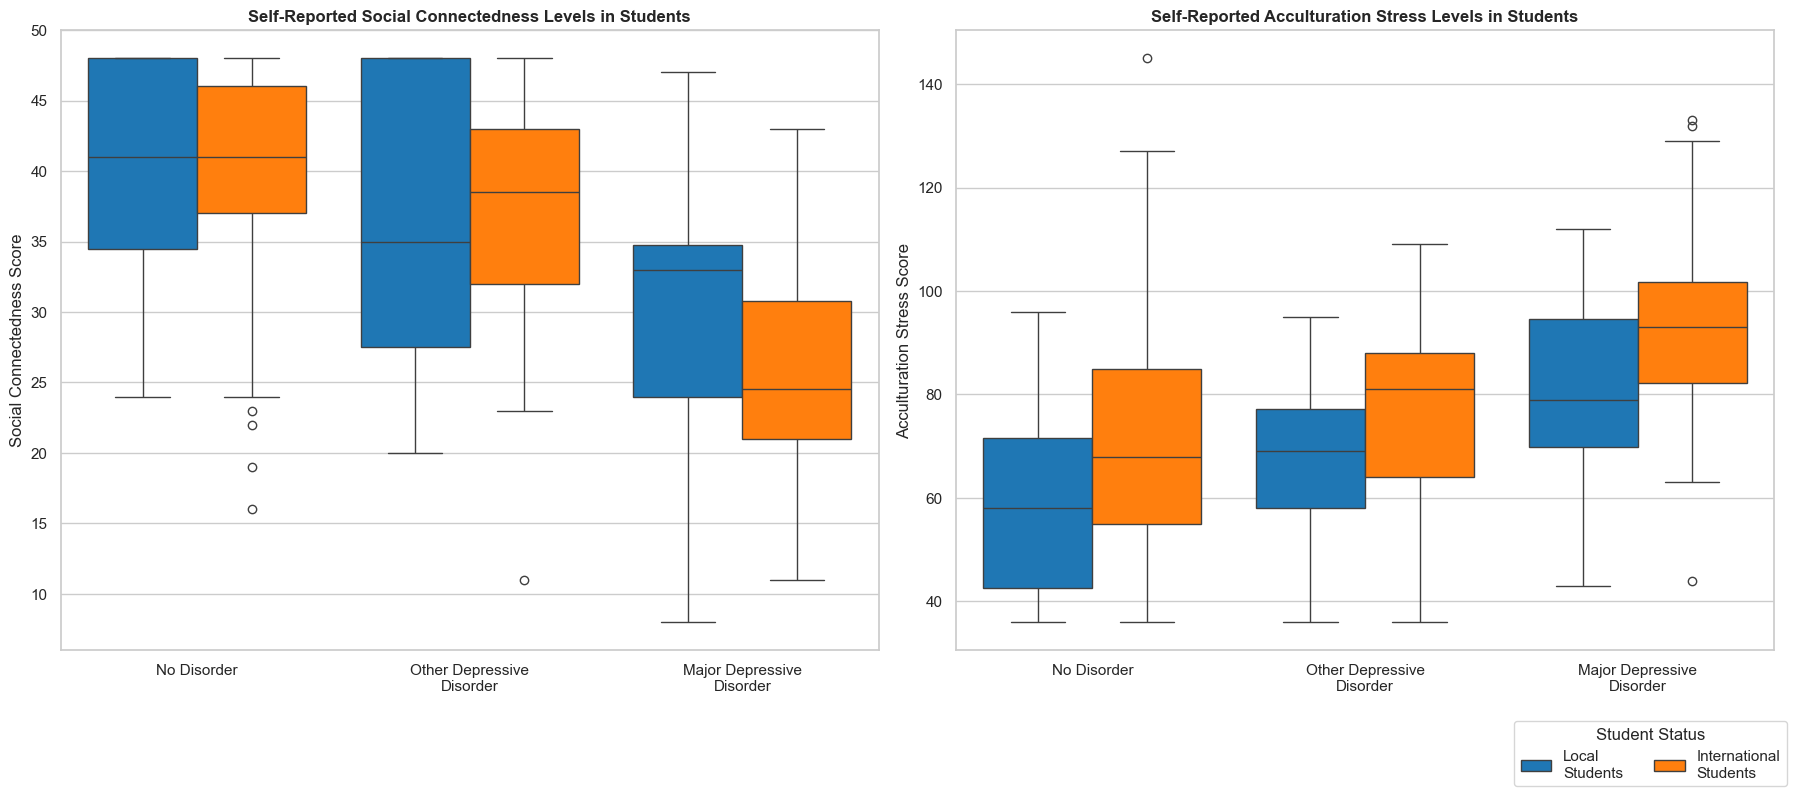

In [242]:
df_2 = df_a.copy()
sns.set(style="whitegrid")

fig,axes = plt.subplots(1, 2, figsize=(18, 8))

df_2["DepType"] = pd.Categorical(df_2["DepType"], categories =["No", "Other", "Major"], ordered=True)
df_2['DepType'] = df_2['DepType'].map({'No': 'No Disorder','Other': 'Other Depressive\nDisorder','Major' : 'Major Depressive\nDisorder'})

df_2["inter_dom"] = pd.Categorical(df_2["inter_dom"], categories=["Dom", "Inter"], ordered=True)
df_2['inter_dom'] = df_2['inter_dom'].map({'Dom': 'Local\nStudents','Inter': 'International\nStudents'})

palette_chosen = sns.color_palette("tab10", 2)

# Social Connectedness Levels
sns.boxplot(data=df_2, x="DepType", y="ToSC", hue="inter_dom", palette=palette_chosen, saturation =1, ax=axes[0])
axes[0].set_title("Self-Reported Social Connectedness Levels in Students", fontweight="bold")
axes[0].set_ylabel("Social Connectedness Score")
axes[0].set_xlabel('')
#axes[0].set_ylim(8, 48)
axes[0].legend_.remove()

# Acculturation Stress Levels
sns.boxplot(data=df_2, x="DepType", y="ToAS", hue="inter_dom", palette=palette_chosen, saturation =1, ax=axes[1])
axes[1].set_title("Self-Reported Acculturation Stress Levels in Students", fontweight="bold")
axes[1].set_ylabel("Acculturation Stress Score")
axes[1].set_xlabel('')
#axes[0].set_ylim(8, 48)
axes[1].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Student Status", loc = "lower right", ncol = 2, frameon=True)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

This Box Plot highlights the Self-Reported Social Connectedness Scores of Students and the Self-Reported Acculturation Stress Levels of Students. From this plot, it can be observed that generally, students with Depressive Disorders reported low Social Connectedness and High Acculturation. Between Local Students and International Students, International Students generally experience less Social Connectedness and high Acculturation Stress. This highlights that some reasons for Depression within International Students in particular is difficulty in feeling connected to others, and struggles with Acculturation. The motivation behind this plot is to determine why International Students observed higher Depression rates compared to Local Students. The limitation of this plot is that it does not include other factors, such as environment which could be a potential reason for Depressive Disorders. This also means that misinterpretation that these are the only 2 factors causing Depression can occur.

### Actionable Plot

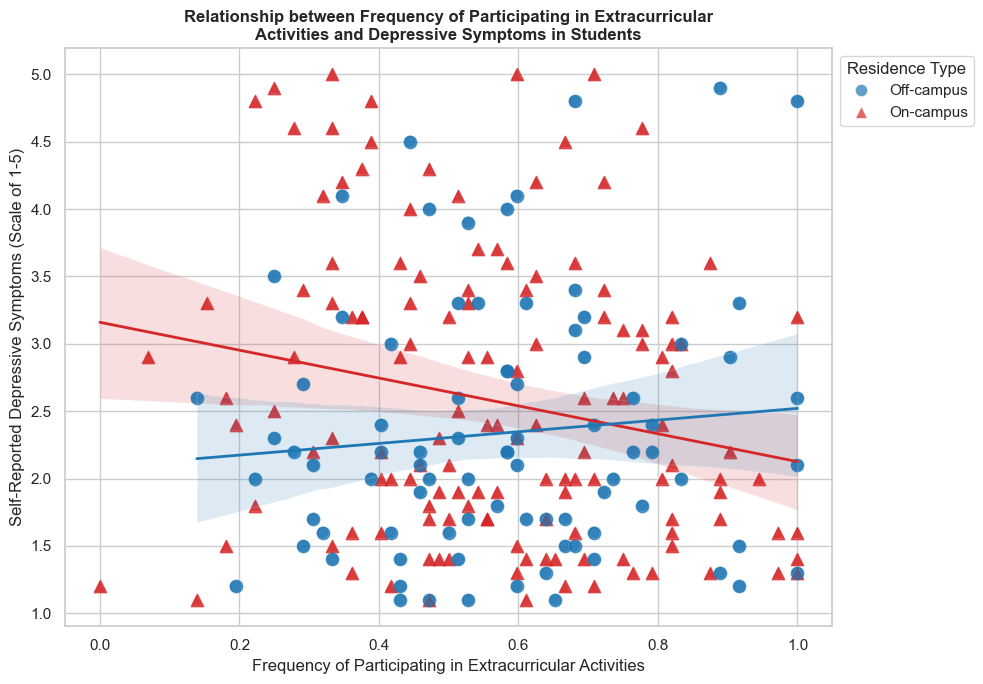

In [243]:
df_4 = df_b.copy()
df_4 = df_4[(df_4["depression"] > 1) & (df_4["depression"] <= 5)]

sns.set(style="whitegrid")

plt.figure(figsize=(10, 7))

df_4["eca_scaled"] = (df_4["extracurricular_activities"] - df_4["extracurricular_activities"].min()) / (df_4["extracurricular_activities"].max() - df_4["extracurricular_activities"].min())


sns.scatterplot(
    data=df_4,
    x="eca_scaled",
    y="depression",
    hue = "living_on_off_campus",
    style="living_on_off_campus",
    markers={
        "On-campus": "^",
        "Off-campus": "o"
    },
    palette={
        "On-campus": "tab:red",
        "Off-campus": "tab:blue"
    },
    s=80,
    alpha=0.7
)

for residence, color, marker in zip(['On-campus', 'Off-campus'], ['tab:red','tab:blue'], ['^','o']):
    subset = df_4[df_4['living_on_off_campus'] == residence]
    sns.regplot(
        data=subset,
        x="eca_scaled",
        y="depression",
        scatter=True,
        marker=marker,
        color=color,
        scatter_kws={"s":80, "alpha":0.7},
        line_kws={"linewidth":2}   # regression line thickness
    )

plt.xlabel("Frequency of Participating in Extracurricular Activities")
plt.ylabel("Self-Reported Depressive Symptoms (Scale of 1-5)")
plt.title("Relationship between Frequency of Participating in Extracurricular\nActivities and Depressive Symptoms in Students", fontweight="bold")

plt.legend(title="Residence Type", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


This Scatter Plot visualises the Frequency of Students in Participating in Extracurricular Activities and their Self-Reported Depressive Symptoms. From this plot, we can observe that for Students living on Campus, there is a negative relationship between their frequency of participating in Extracurricular Activities and their Self-Reported Depressive Symptoms. This is unlike Students who stay Off-Campus. In the Singapore Context, oftentimes International Students live on Campus. Assuming so, this plot highlights that more involvement in Extracurricular Activities can be encouraged and emphasised for International Students to mitigate high rates of Depression within International Students, driving Campus Policy. The motivation behind this plot is to explore what can be done by Campuses to mitigate Depression. The limitation of this plot is that the scatter is not as distributed to form a concrete relationship.